# MEI Data Science Taught Course - World Development Indicators

# Introduction

In this notebook you explore the differences between high income and low income countries across a range of different measures, but particularly life expectancy, using the Seaborn plotting library.

You will first create plots that focus on a single numerical feature, grouped by other categorical features, before using two-dimensional plots to look for association between features.

## Import libraries and data

In [ ]:
# import pandas 
import pandas as pd

# import seaborn and set the display style to "talk"
import seaborn as sns
sns.set_context("talk")

In [ ]:
# import the data
wdi_data = pd.read_csv('/kaggle/input/world-demographic-indicators-extract/wdi_wide.csv')

# display the data set to check
wdi_data

This is an extract of development indicators for individual countries from World Bank. The data also includes geographical indicators, such as region.

Features:
* **Country Name**
* **Region**: *Large scale region of the world*
* **Subregion**: *More specific region*
* **Intermediate Region**: *Local region if given, otherwise same as subregion*
* **GNI**: *Gross National Income (US dollars)*
* **Internet use**: *Percentage of population who use the internet (%)*
* **International tourism**: *Number of tourist arrivals per year*
* **Life expectancy, female**: *Life expectancy at birth in years, female (years)*
* **Life expectancy, male**: *Life expectancy at birth in years, male (years)*
* **Physicians**: *Number of physicians per 1,000 people*
* **Population**: *Total population*
* **Women in national parliament**: *Proportion of women in national parliaments (%)*
* **Tertiary education, female**: *Gross enrolment ratio for tertiary school, female (%)*
* **Tertiary education, male**: *Gross enrolment ratio for tertiary school, male (%)*
* **Greenhouse gas emissions**: *Emissions CO2 equivalent (kilotons)*
* **High Income Economy**: *Whether the GNI per capita exceeds 2020 World Bank threshold of $12,696 (Yes/No)*


In [ ]:
# display the size of the data set and the data types
wdi_data.info()

# Preparing the data

## Feature engineering

Gross National Income (GNI) is an absolute value. It's fairer to use GNI per capita.

In [ ]:
# Divide GNI by population, round it the nearest cent, and assign it to a new feature
wdi_data['GNI per capita'] = (wdi_data['GNI'] / wdi_data['Population']).round(2)
wdi_data['GNI per capita']

# Visualisations for categorical features

## Using `value_counts`

### How many countries are there in each region?

In [ ]:
wdi_data['Region'].value_counts()

### How many high income economies are there?

In [ ]:
wdi_data['High Income Economy'].value_counts()

## Using `crosstab`

The `pd.crosstab` function in pandas produces a two-way table.

### Where are the high income economies?

In [ ]:
# display a 2-way table
pd.crosstab(wdi_data['High Income Economy'], wdi_data['Region'])

In [ ]:
# bar chart split by a category (frequencies)
sns.displot(data=wdi_data, x='Region', hue='High Income Economy', multiple='stack', aspect=2);

In crosstabs and bar charts you can also display the data by proportions.

In [ ]:
# two-way table (proportions)
pd.crosstab(wdi_data['High Income Economy'], wdi_data['Region'], normalize='index')

In [ ]:
# bar chart split by a category (proportions)
sns.displot(data=wdi_data, x='Region', hue='High Income Economy', stat='proportion', multiple='fill',aspect=2);

# Visualisations for a single numerical feature

## Using `groupby`

### Are there any differences across the numerical features for high and low income countries?

In [ ]:
# create a list of the features to be explored
features=['Internet use', 'International tourism', 'Life expectancy, female', 'Life expectancy, male', 'Physicians', 'Population', 'Women in national parliament', 'Tertiary education, female', 'Tertiary education, male', 'Greenhouse gas emissions', 'High Income Economy', 'GNI per capita']

# use group by to get the means of these for low and high income
wdi_data.groupby('High Income Economy')[features].mean().round(2)

There is a difference in mean life expectancy, both female and male, of almost ten years. We'll explore female life expectancy further using some visualisations. Later you'll look at male life expectancy yourself.

## Creating histograms with `displot`

The `displot` function in Seaborn is used to display the shape of distributions. See https://seaborn.pydata.org/generated/seaborn.displot.html for more information.

The default is a histogram. Note that Seaborn uses the form of a histogram with equal interval widths and frequency on the vertical axis.

### What does the distribution of life expectancy look like?

In [ ]:
# aspect=2 - plot is twice as wide as it is high
sns.displot(data=wdi_data, x='Life expectancy, female', aspect=2);

### How does the distribution of life expectancy vary by region?

The code below shows one histogram per region.

In [ ]:
# create histograms of life expectancy by region
# col='Region' - one column per region
sns.displot(data=wdi_data, x='Life expectancy, female', col='Region');

## Creating KDE plots with `displot`

A _kernel density estimation_ plot smoothes out the histogram to give an estimate of what the continuous distribution looks like.

### How does the distribution of life expectancy differ between high and low income economies?

You can use the `hue` parameter to draw separate curves for high and low income economies.

In [ ]:
# create a kde plot with one curve for each income category
# hue='High Income Economy' - draw separate curves for the two subsets
sns.displot(data=wdi_data, kind='kde', x='Life expectancy, female', hue='High Income Economy', aspect=2);

## Creating box plots with `catplot`

In Seaborn `catplot` creates charts of a single variable with the option of grouping this by additional categories. You can use it to create box plots and violin plots.

For more information see: https://seaborn.pydata.org/generated/seaborn.catplot.html

### How does average life expectancy vary by region?

In [ ]:
# box plots for life expectancy categorised by region
sns.catplot(data=wdi_data, kind='box', x='Life expectancy, female', y='Region', aspect=2);

### Is average life expectancy higher in high income economies in each region?

In [ ]:
# box plots for life expectancy categorised by region and income category
sns.catplot(data=wdi_data, kind='box', x='Life expectancy, female',y='Region', hue='High Income Economy', aspect=2);

## Creating violin plots with `catplot`

A violin plot combines a box plot with a KDE, and can be split by a binary category.

### How does life expectancy vary by both income category and region?

In [ ]:
# violin plot for life expectancy categorised by region and income category
# split=True - show the distributions side by side under two conditions
sns.catplot(data=wdi_data, kind='violin', x='Life expectancy, female',y='Region', hue='High Income Economy', split=True, aspect=2);

# Task 1

You can now create diagrams to explore male life expectancy by copying the code above and changing `Life expectancy, female` to `Life expectancy, male`.

### Create a set of histograms that shows the distribution of male life expectancy in each region

In [ ]:
# create histograms of male life expectancy by region
# col='Region' - one column per region


### Create a KDE plot to compare the distributions of male life expectancy for high and low income economies

In [ ]:
# create a kde plot with one curve for each income category
# hue='High Income Economy' - draw separate curves for the two subsets


### Create a set of box plots of male life expectancy grouped by region

In [ ]:
# box plots for male life expectancy categorised by region


### Create a violin plot that shows how male life expectancy varies by both region and income category

In [ ]:
# violin plot for male life expectancy categorised by region and income category
# split=True - show the distributions side by side under two conditions


Before continuing, check your work.

* Your histograms grouped by region should look like this

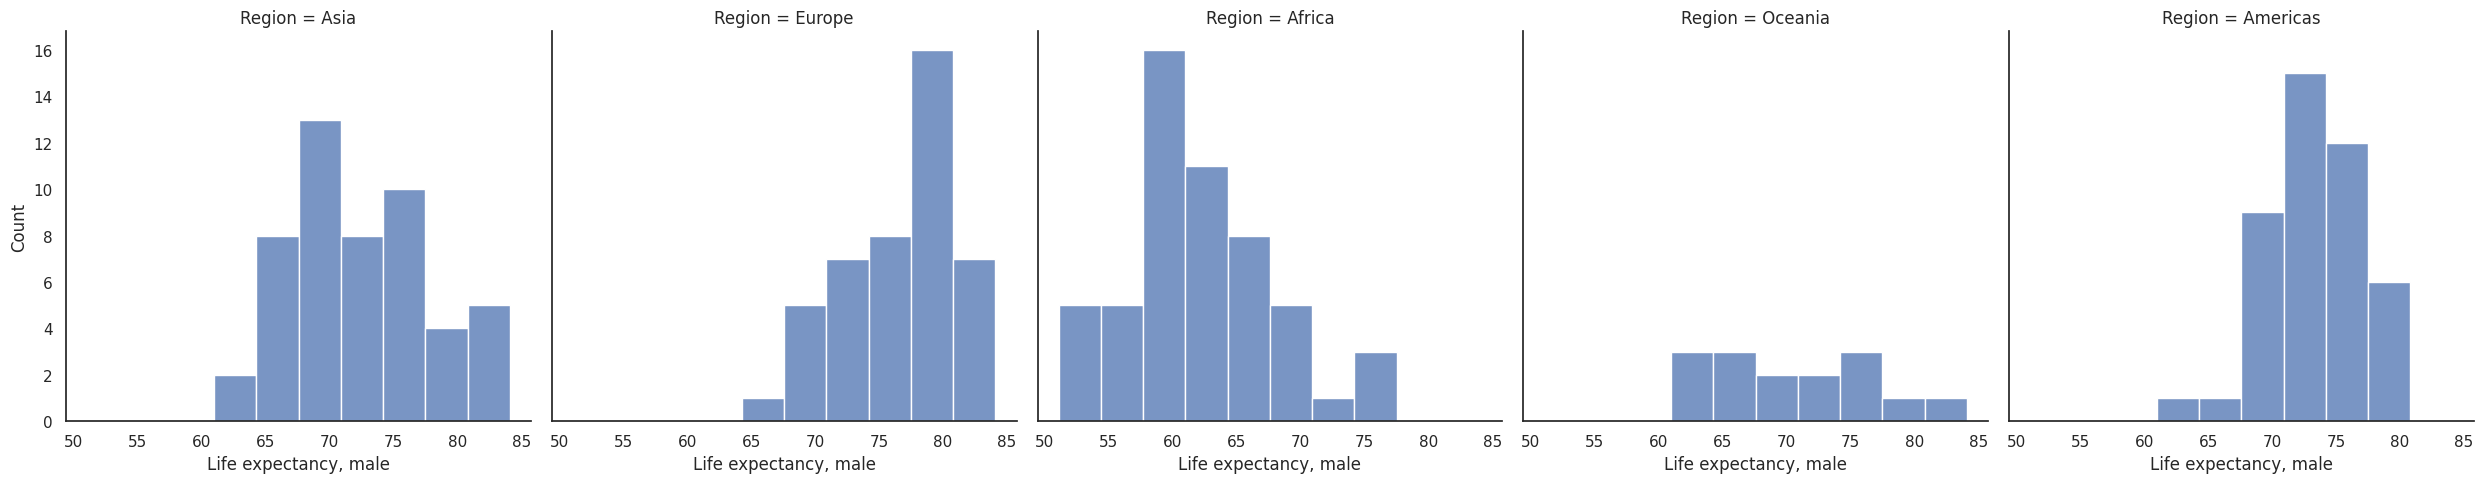

* Your KDE plot should look like this

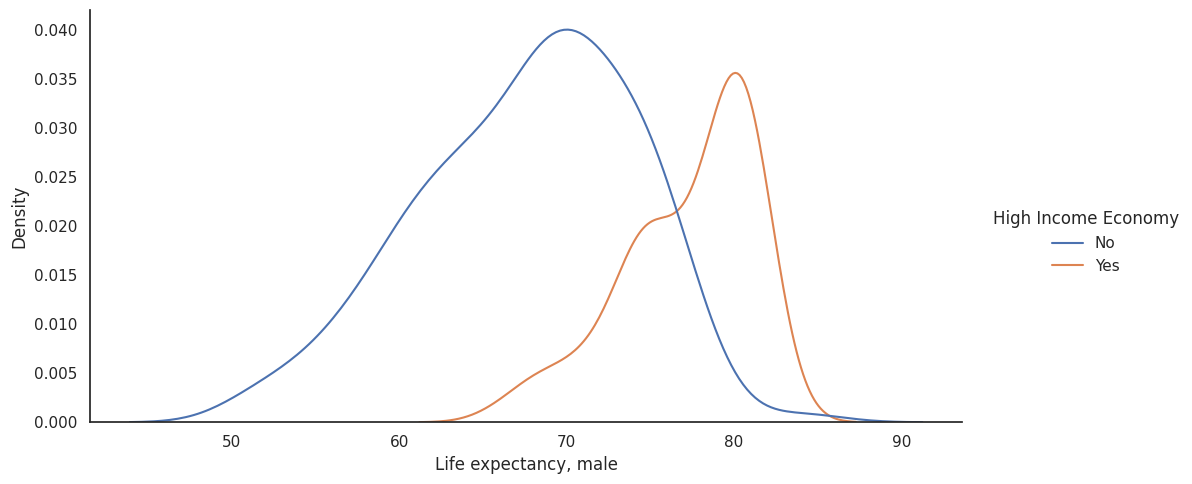

* Your box plots should look like this

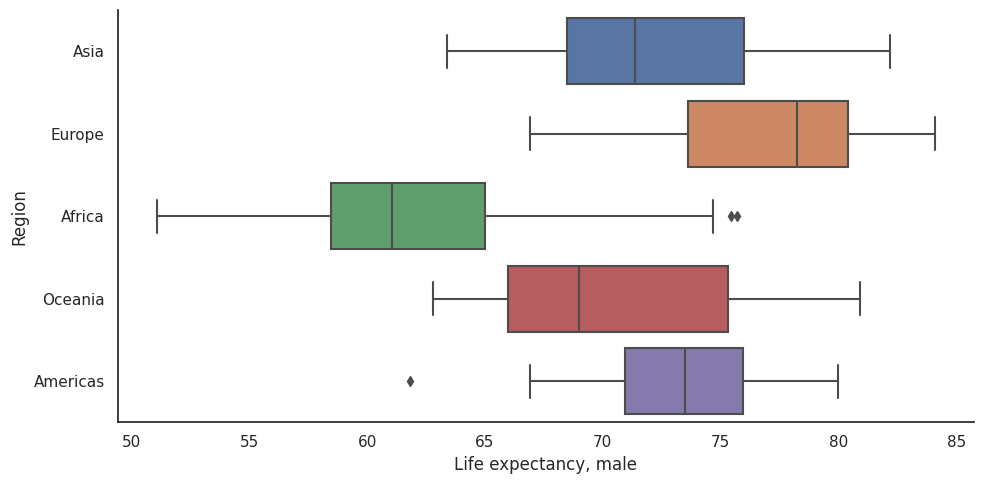

* Your violin plots should look like this

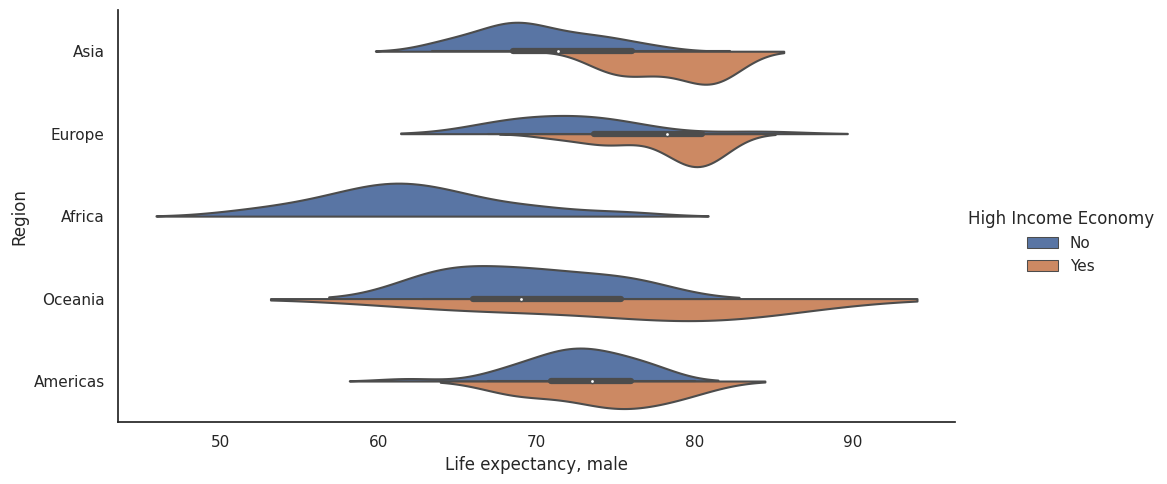

### Explore the differences in another feature for high and low income economies

Choose another feature and create some histograms, KDE plots, bar charts and violin plots to visualise how it varies by income category and/or region.

# Visualisations for pairs of numerical features

## Creating scatter plots with `relplot`

Scatter plots are useful to show association between two numerical features. You can create scatter plots using Seaborn's `relplot` command. See https://seaborn.pydata.org/generated/seaborn.relplot.html for documentation.

### Is there any association between GNI per capita and life expectancy?

As life expectancy is on average higher in high income countries, we might expect to see some kind of association between GNI per capita and life expectancy. We'll start with female life expectancy and you can look at male life expectancy yourself.

In [ ]:
# create a scatter plot
sns.relplot(data=wdi_data, x='GNI per capita', y='Life expectancy, female', aspect=2);

### Does the association vary by region?

You can add a third, categorical feature to a scatter plot by changing the colour of the points.

In [ ]:
# hue='Region' - colour the points according to region
sns.relplot(data=wdi_data, x='GNI per capita', y='Life expectancy, female', hue='Region', aspect=2);

## Task 2

### Explore relationships between female and male life expectancy and other features

Use `relplot` to explore relationships between female life expectancy and some of the other numerical features. Are these relationships similar for male life expectancy?

# Appendix: setting titles and axes
You can set the title of the visualisation and the axes, as well as defining the range of values on each axes. The code below gives an example of this.

In [ ]:
# plot the visualisation
plot = sns.displot(data=wdi_data, x='Life expectancy, female', aspect=2);

# Label the axes and show the plot
plot.set(xlim=(50,90),xlabel="Female life expectancy (years)", ylabel="Frequency", title="Average female life expectancy")
plot;